<a href="https://colab.research.google.com/github/charlesrogers431/Gaming-Mental-Health-and-Wellbeing-Analysis/blob/main/MachineLearningGaming%26MentalHealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro and Setup

In [91]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

url = 'https://raw.githubusercontent.com/charlesrogers431/Gaming-Mental-Health-and-Wellbeing-Analysis/main/Gaming%20and%20Mental%20Health.csv'
df = pd.read_csv(url)

In [54]:
# these will be used for handling the data
import pandas as pd
import numpy as np

# these will be used to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)  # show all columns
sns.set_style('whitegrid')

print("Libraries loaded.")



Libraries loaded.


In [55]:
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 1000 rows, 27 columns


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,NaN,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,NaN,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,Poor,1.62,2.0,Withdrawn,Daily,True,True,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,Average,2.44,NaN,Angry,Daily,True,False,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


# Exploratory Data Analysis (EDA)

In [56]:
# Prints a summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

*Grades_gpa* and *Work_productivity_score* contain non-null (missing) values.
Why? --> This lack of data is likely because GPA only applies to students, and work productivty scores only apply to those who work. The average age of the data set is 20, while the min=13 and the max=35. Those older participants won't have GPAs to report, while the middle-schooler won't work.

In [57]:
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


Worth noting that the max value for daily gaming hours is 15 and the median sleep hours is 5.7 per night.
My immediate hypothesis is that there is likely a correlation between high gaming hours and low sleep hours.

# Data Cleaning and Preprocessing

In [58]:
# Show count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_table[missing_table['Missing Count'] > 0])

                         Missing Count  Missing %
grades_gpa                         246       24.6
work_productivity_score            326       32.6


<function matplotlib.pyplot.show(close=None, block=None)>

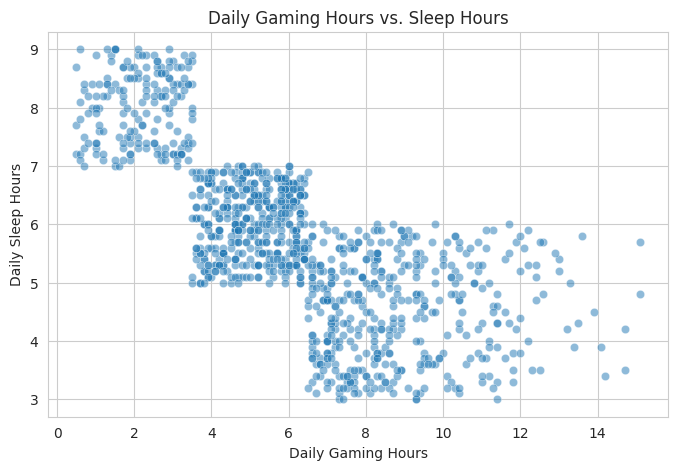

In [59]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='daily_gaming_hours', y='sleep_hours', alpha=0.5)
plt.title('Daily Gaming Hours vs. Sleep Hours')
plt.xlabel('Daily Gaming Hours')
plt.ylabel('Daily Sleep Hours')
plt.show

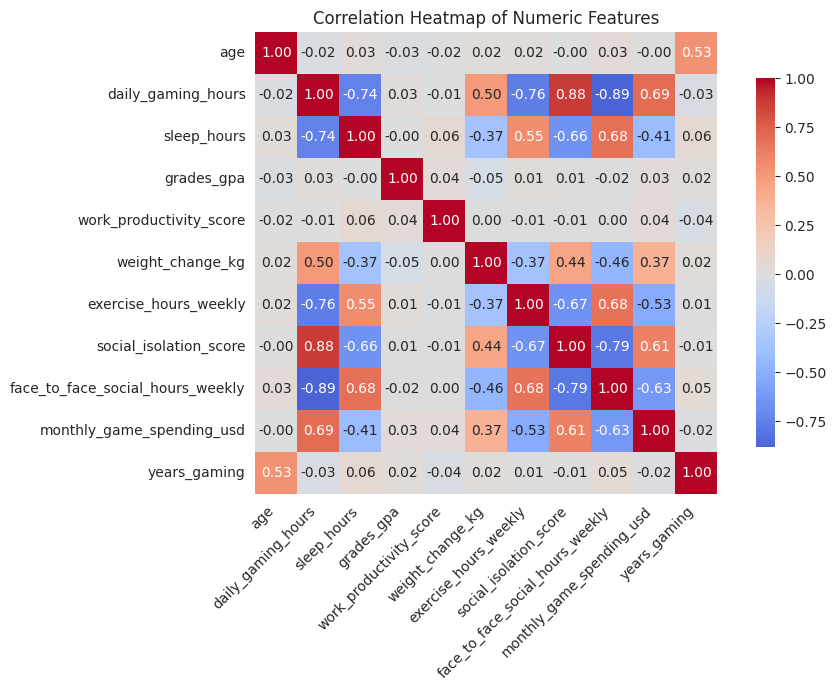

In [60]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

Right off the bat, the strongest relationships are:


1. Face-to-face social hours weekly and daily gaming hours --> -0.89
2. Social isolation score and daily gaming hours --> 0.88
3. Social isolation score and face-to-face social hours weekly --> -0.79
4. Exercise hours weekly and daily gaming hours --> -0.76
5. Sleep hours and daily gaming hours --> -0.74  



In [61]:
# Let's look at the age distribution for people with no listed GPA and people with no work productivity score

print("Average age of people MISSING grades_GPA:", df[df['grades_gpa'].isnull()]['age'].mean().round(1))
print("Average age of people WITH grades_GPA:", df[df['grades_gpa'].notnull()]['age'].mean().round(1))
print()
print("Average age MISSING work_productivity:", df[df['work_productivity_score'].isnull()]['age'].mean().round(1))
print("Average age WITH work_productivity:", df[df['work_productivity_score'].notnull()]['age'].mean().round(1))


Average age of people MISSING grades_GPA: 26.3
Average age of people WITH grades_GPA: 18.6

Average age MISSING work_productivity: 16.4
Average age WITH work_productivity: 22.4


In [62]:
# Since grades_gpa and work_productivity only apply to subsets of the sample, let's drop them and focus that energy on academic_work_performance,
# which captures both simultaneously and applies universally.

df_clean = df.drop(['grades_gpa', 'work_productivity_score'], axis=1)

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (1000, 27)
Cleaned shape: (1000, 25)


In [63]:
# Any missing values left?

print(df_clean.isnull().sum().sum())

0


In [64]:
# Record_id is just a PK, so we can drop it before doing any real analysis.

df_clean = df_clean.drop('record_id', axis=1)
print(f"Shape after dropping record_id: {df_clean.shape}")

Shape after dropping record_id: (1000, 24)


In [65]:
# Check the actual unique values in each ordinal column
for col in ['sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'mood_swing_frequency', 'gaming_addiction_risk_level']:
    print(col, "→", sorted(df_clean[col].unique()))

sleep_quality → ['Fair', 'Good', 'Insomnia', 'Poor', 'Very Poor']
sleep_disruption_frequency → ['Always', 'Never', 'Often', 'Rarely', 'Sometimes']
academic_work_performance → ['Average', 'Below Average', 'Excellent', 'Failing', 'Good', 'Poor']
mood_swing_frequency → ['Daily', 'Never', 'Often', 'Rarely', 'Sometimes']
gaming_addiction_risk_level → ['High', 'Low', 'Moderate', 'Severe']


In [66]:
from matplotlib.colors import LinearSegmentedColormap
# Let's define the valid order for each ordinal columnn (from low to high)

ordinal_maps = {
    'sleep_quality': ['Insomnia', 'Very Poor', 'Poor', 'Fair', 'Good'],
    'sleep_disruption_frequency': ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
    'academic_work_performance': ['Failing', 'Poor', 'Below Average', 'Average', 'Good', 'Excellent'],
    'mood_swing_frequency': ['Never', 'Rarely', 'Sometimes', 'Often', 'Daily'],
    'gaming_addiction_risk_level': ['Low', 'Moderate', 'High', 'Severe']
}

# Now convert the category to its position in the ordered list

for col, order in ordinal_maps.items():
  df_clean[col] = df_clean[col].apply(lambda x: order.index(x) if x in order else None)

print("Missing values after encoding:", df_clean[list(ordinal_maps.keys())].isnull().sum().sum())
df_clean[list(ordinal_maps.keys())].head()

Missing values after encoding: 0


,sleep_quality,sleep_disruption_frequency,academic_work_performance,mood_swing_frequency,gaming_addiction_risk_level
0,1,2,2,0,3
1,3,1,4,3,0
2,3,3,1,1,3
3,3,3,1,4,2
4,2,0,3,4,1


In [67]:
nominal_cols = ['gender', 'game_genre', 'primary_game', 'gaming_platform', 'mood_state']
for col in nominal_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")

gender: 3 unique values
game_genre: 7 unique values
primary_game: 24 unique values
gaming_platform: 4 unique values
mood_state: 9 unique values


In [68]:
# Drop the primary_game column since it adds little/no analytical value, and one-hot encoding would create 24(!!) additional columns.

df_clean = df_clean.drop('primary_game', axis=1)
print(f"Shape after dropping record_id: {df_clean.shape}")

Shape after dropping record_id: (1000, 23)


In [69]:
# One-hot encode the nominal columns (no natural order)
nominal_cols = ['gender', 'game_genre', 'gaming_platform', 'mood_state']
df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=False)

print(f"Shape before: {df_clean.shape}")
print(f"Shape after:  {df_encoded.shape}")
df_encoded.head()

Shape before: (1000, 23)
Shape after:  (1000, 42)


,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,gender_Female,gender_Male,gender_Other,game_genre_Battle Royale,game_genre_FPS,game_genre_MMO,game_genre_MOBA,game_genre_Mobile Games,game_genre_RPG,game_genre_Strategy,gaming_platform_Console,gaming_platform_Mobile,gaming_platform_Multi-platform,gaming_platform_PC,mood_state_Angry,mood_state_Anxious,mood_state_Depressed,mood_state_Euphoric,mood_state_Excited,mood_state_Irritable,mood_state_Normal,mood_state_Restless,mood_state_Withdrawn
0,17,11.1,3.7,1,2,2,0,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,3,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False
1,21,3.0,7.2,3,1,4,3,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,0,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
2,23,7.6,4.4,3,3,1,1,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,3,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
3,20,7.2,5.1,3,3,1,4,True,True,False,True,True,0.2,5.2,4,9.1,51.60,7,2,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True
4,18,6.8,3.4,2,0,3,4,True,False,False,False,False,0.5,6.1,4,4.5,32.57,1,1,False,True,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False


# Association Rule Mining

In [70]:
# We need to install mlxtend so we can do Association Rule Mining, which must be installed.

!pip install mlxtend -q

from mlxtend.frequent_patterns import apriori, association_rules
print("mlxtend installed.")

mlxtend installed.


In [71]:
symptom_cols = [
    'withdrawal_symptoms',
    'loss_of_other_interests',
    'continued_despite_problems',
    'eye_strain',
    'back_neck_pain'
]

symptoms = df_encoded[symptom_cols]
print(symptoms.head())
print(f"\nShape: {symptoms.shape}")

   withdrawal_symptoms  loss_of_other_interests  continued_despite_problems  \
0                 True                    False                        True   
1                False                    False                       False   
2                 True                     True                        True   
3                 True                     True                       False   
4                 True                    False                       False   

   eye_strain  back_neck_pain  
0        True           False  
1       False           False  
2       False            True  
3        True            True  
4       False           False  

Shape: (1000, 5)


In [72]:
# Find frequent itemsets (of symptoms) when they appear in at least 5% of records
frequent_itemsets = apriori(symptoms, min_support=0.05, use_colnames=True)

# Sort by frequency of occurence
frequent_itemsets = frequent_itemsets.sort_values('support', ascending = False)
print(frequent_itemsets.head(15))

    support                                           itemsets
3     0.497                                       (eye_strain)
4     0.348                                   (back_neck_pain)
1     0.324                          (loss_of_other_interests)
0     0.288                              (withdrawal_symptoms)
14    0.236                       (back_neck_pain, eye_strain)
10    0.224              (eye_strain, loss_of_other_interests)
7     0.201                  (eye_strain, withdrawal_symptoms)
11    0.195          (back_neck_pain, loss_of_other_interests)
8     0.185              (back_neck_pain, withdrawal_symptoms)
5     0.164     (loss_of_other_interests, withdrawal_symptoms)
2     0.139                       (continued_despite_problems)
20    0.134  (eye_strain, back_neck_pain, withdrawal_symptoms)
22    0.126  (eye_strain, back_neck_pain, loss_of_other_int...
16    0.112  (loss_of_other_interests, eye_strain, withdraw...
17    0.102  (loss_of_other_interests, back_neck_pain, 

In [73]:
# Turn these frequent itemsets into directional rules, so X --> Y
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Now, we sort these by lift
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules.sort_values('lift', ascending = False)

print(f"Found {len(rules)} rules\n")
rules.head(10)

Found 39 rules



,antecedents,consequents,support,confidence,lift
31,"(continued_despite_problems, back_neck_pain)",(withdrawal_symptoms),0.058,0.674419,2.341731
29,"(continued_despite_problems, eye_strain)",(withdrawal_symptoms),0.062,0.659574,2.290189
22,(continued_despite_problems),(withdrawal_symptoms),0.089,0.640288,2.223221
37,"(continued_despite_problems, loss_of_other_int...",(withdrawal_symptoms),0.050,0.625000,2.170139
9,"(back_neck_pain, eye_strain)",(withdrawal_symptoms),0.134,0.567797,1.971516
10,"(withdrawal_symptoms, eye_strain)",(back_neck_pain),0.134,0.666667,1.915709
32,"(continued_despite_problems, withdrawal_symptoms)",(back_neck_pain),0.058,0.651685,1.872659
25,"(loss_of_other_interests, eye_strain, back_nec...",(withdrawal_symptoms),0.067,0.531746,1.846340
6,(withdrawal_symptoms),(back_neck_pain),0.185,0.642361,1.845865
5,(back_neck_pain),(withdrawal_symptoms),0.185,0.531609,1.845865


Association mining revealed that physical, behavioral and psychological symptoms of problematic gaming cluster together: gamers showing physical strain and compulsive continuation were over twice as likely (2.34x) to also exhibit signs of withdrawal symptoms. This insight suggests that these symptoms share a common root in gaming dependency, rather than simply occuring indepdently of one another.

# Clustering (K-Means)

In [74]:
from sklearn.preprocessing import StandardScaler
print("sklearn installed.")

sklearn installed.


In [75]:

# Let's use the scaler to scale some of the attributes so they are all on equal footing

cluster_features = [
    'age',
    'daily_gaming_hours',
    'sleep_hours',
    'exercise_hours_weekly',
    'social_isolation_score',
    'face_to_face_social_hours_weekly',
    'monthly_game_spending_usd'
]

X = df_encoded[cluster_features]

# Scale every feature so mean=0 & std=1. This prevents any single variable from dominating the rest.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)
print("Feature means after scaling (should say ~0):", X_scaled.mean(axis=0).round(2))

Scaled shape: (1000, 7)
Feature means after scaling (should say ~0): [-0.  0. -0.  0.  0.  0. -0.]


"Years_gaming" was excluded.
The goal is to analyze the *current* patterns of behavior (both lifestyle and wellbeing), and this attribute simply adds extra historical data to each record, which is not pertinent to the current study. This keeps clusters focused on present day behavioral profiles rather than how long a participant has been gaming for.  

In [76]:
from sklearn.cluster import KMeans
print("sklearn clustering installed.")

sklearn clustering installed.


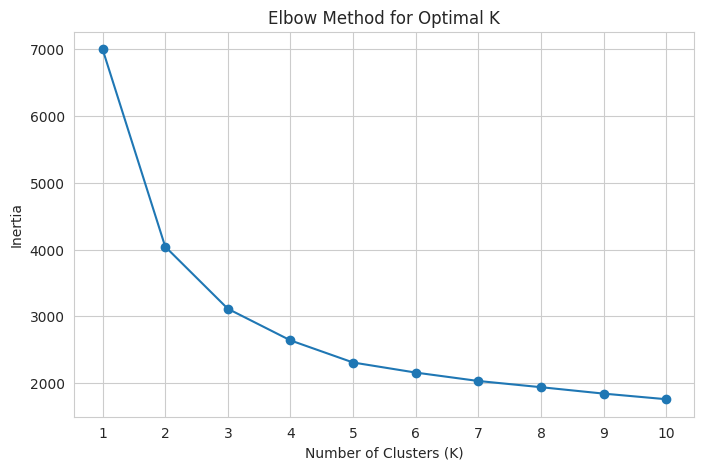

In [77]:
# We will try K from 1-10 and select the one where adding additional clusters stops notably improving the fit.

inertias = []
K_range = range(1,11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)

# Now, we plot the elbow curve as a visual.

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

During the initial EDA, I noticed in the scatterplot what appeared to be 3 distinct clusters of participants. Using the Elbow Method, I was able to confirm 3 clusters mathematically, as K=3 is the optimal number of clusters. The original hypothesis and validated visualization concur.

In [78]:
# Fit K-Means with the optimal K, 3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Now we attatch the cluster label back to a copy of the unscaled data so we can interpret clusters in real-world units.

df_clustered = df_encoded.copy()
df_clustered['cluster'] = clusters

# How many gamers landed in each cluster? Remember that we had 1000 rows, so there were 1000 gamers.

print(df_clustered['cluster'].value_counts().sort_index())

cluster
0    485
1    318
2    197
Name: count, dtype: int64


In [79]:
# Let's calculate the average of key features for each cluster.

profile_cols = [
    'daily_gaming_hours',
    'sleep_hours',
    'exercise_hours_weekly',
    'social_isolation_score',
    'face_to_face_social_hours_weekly',
    'monthly_game_spending_usd',
    'age',
    'gaming_addiction_risk_level'
]

cluster_profiles = df_clustered.groupby('cluster')[profile_cols].mean().round(2)
print(cluster_profiles)


         daily_gaming_hours  sleep_hours  exercise_hours_weekly  \
cluster                                                           
0                      6.39         5.29                   6.74   
1                      3.17         7.18                   8.57   
2                     10.39         4.52                   4.83   

         social_isolation_score  face_to_face_social_hours_weekly  \
cluster                                                             
0                          4.06                              7.29   
1                          1.79                             11.40   
2                          6.77                              2.49   

         monthly_game_spending_usd    age  gaming_addiction_risk_level  
cluster                                                                 
0                            77.04  20.20                         0.89  
1                            34.58  20.92                         0.00  
2                         

In [80]:
# Transpose so features are rows and clusters are columns — much easier to read
cluster_profile = df_clustered.groupby('cluster')[profile_cols].mean().round(2).T
cluster_profile.columns = ['Cluster 0', 'Cluster 1', 'Cluster 2']
cluster_profile

,Cluster 0,Cluster 1,Cluster 2
daily_gaming_hours,6.39,3.17,10.39
sleep_hours,5.29,7.18,4.52
exercise_hours_weekly,6.74,8.57,4.83
social_isolation_score,4.06,1.79,6.77
face_to_face_social_hours_weekly,7.29,11.40,2.49
monthly_game_spending_usd,77.04,34.58,288.61
age,20.20,20.92,20.44
gaming_addiction_risk_level,0.89,0.00,2.48


In [81]:
# Now we name the clusters based on the behavioral profiles.

cluster_names = {
    1: 'Balanced Gamers',
    0: 'Moderate / At-Risk Gamers',
    2: 'High-Risk Gamers'
}
df_clustered['cluster_name'] = df_clustered['cluster'].map(cluster_names)

print(df_clustered['cluster_name'].value_counts())

cluster_name
Moderate / At-Risk Gamers    485
Balanced Gamers              318
High-Risk Gamers             197
Name: count, dtype: int64


# Classification - Decision Trees

Goal for Classification: predict a gamer's addiction risk level based off their behavioral data.

In [82]:
from sklearn.model_selection import train_test_split
print('train_test_split installed.')

train_test_split installed.


In [83]:
# What do we want to predict?
y = df_encoded['gaming_addiction_risk_level']

# Now we drop everything other than our target feature:
x = df_encoded.drop(columns=['gaming_addiction_risk_level'])

# Now we set up the train and test splits. 80% - 20% is the split we will use.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {x_train.shape} gamers")
print(f"Test set: {x_test.shape} gamers")
print(f"\nFeatures used: {x.shape[1]}")

Training set: (800, 41) gamers
Test set: (200, 41) gamers

Features used: 41


In [84]:
# Check to see if df_encoded still has the cluster and cluster_names in it.
print([c for c in X.columns if 'cluster' in c.lower()])

[]


In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [86]:
# First, we train the model on the training data.
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(x_train, y_train)

# Then we predict on the test data.
y_pred = tree.predict(x_test)

# Test the accuracy.
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}\n")
print(classification_report(y_test, y_pred))

Accuracy: 98.00%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38
           2       1.00      0.87      0.93        31
           3       0.88      1.00      0.93        28

    accuracy                           0.98       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.98      0.98      0.98       200



The accuracy score tells us that out of 200 gamers the model was tested on, it was able to accurately predict the addiction risk level for 196 of them. That is a very strong rate.
The 4 rows (0,1,2,3) reflect the risk levels:
0 = Low | 1 = Moderate | 2 = High | 3 = Severe.
The model never confuses a Low-Risk gamer with a Severe one, it only stumbles on the grey boundary between High and Severe, which makes sense logically. This tells us that the model has learned the practical structure of the data: someone with a low-risk level won't be confused with someone who is at severe-risk.


It is important to note that 98% accuracy is suspiciously high for real-world data. Based on the accuracy, I have to assume that this is likely a synthetic dataset with underlying patterns. With real-world data, I would expect a lower accuracy %, and would focus on recall for the High/Severe-risk groups because missing an at-risk gamer is much more costly/dangerous than a false alarm.

In [87]:
import pandas as pd

                   feature  importance
        daily_gaming_hours    0.466742
   loss_of_other_interests    0.232154
continued_despite_problems    0.157759
       withdrawal_symptoms    0.134658
          weight_change_kg    0.005085
     exercise_hours_weekly    0.003602
sleep_disruption_frequency    0.000000
                       age    0.000000
               sleep_hours    0.000000
 academic_work_performance    0.000000


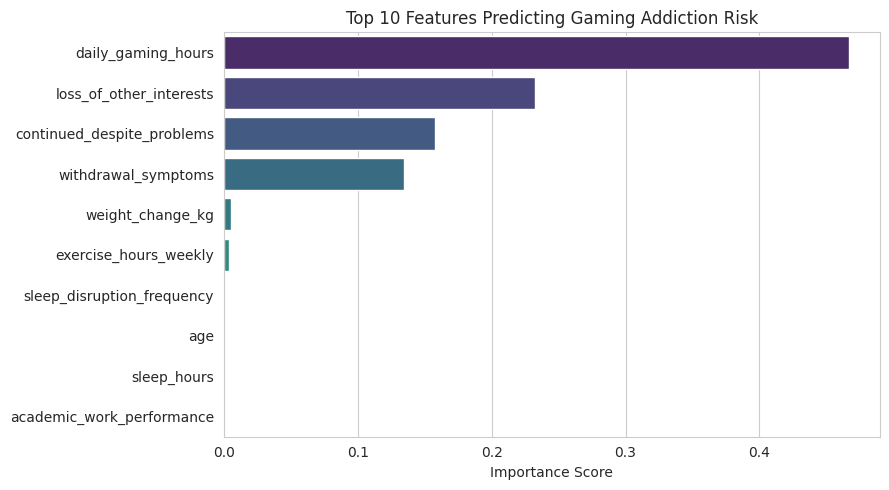

In [88]:
# Use X_train.columns to match exactly what the model was trained on
importances = pd.DataFrame({
    'feature': x_train.columns,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(10).to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=importances.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features Predicting Gaming Addiction Risk')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

To conclude Classification modeling:
The association rule mining found that withdrawal symptoms, loss of interest, and continued play despite problems cluster together with a lift of 2.34. When I did the decision tree classification, this model confirmed that these 3 behavioral symptoms, alongside the raw daily gaming hours feature, were the dominant predictors of addiction risk. Essentially, two separate models agree on the same features being the warning signs for gaming addiction.

# Linear Regression to Predict Sleep Hours

How well can we predict a gamer's sleep hours from their behavior, and what's the relationship?

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

y_reg = df_encoded['sleep_hours']

# Features that we will use for behavioral predictors
reg_features = [
    'daily_gaming_hours',
    'exercise_hours_weekly',
    'social_isolation_score',
    'face_to_face_social_hours_weekly',
    'monthly_game_spending_usd',
    'age',
    'years_gaming'
]
X_reg = df_encoded[reg_features]

# Now split the set into our trianing and testing data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Now train the model
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

# Set up the prediction on the test set
y_pred_r = reg.predict(X_test_r)

# Evaluate the performance of the model using the R score
r2 = r2_score(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)

print(f"R-squared score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f} hours")

R-squared score: 0.593
Mean Absolute Error: 0.74 hours


Interestingly, my regression on sleep came back at R² 0.59, which was much lower than my 98% classification accuracy. I'd argue that's actually the more credible result. Sleep is influenced by many factors outside gaming behavior, so explaining 59% of its variance with behavioral features alone is a realistic, honest outcome rather than an inflated one.

In [90]:
# Find the coefficient for each of the features.
coefficients = pd.DataFrame ({
    'feature': reg_features,
    'coefficient': reg.coef_
}).sort_values('coefficient')

print(coefficients.to_string(index=False))

                         feature  coefficient
              daily_gaming_hours    -0.392898
          social_isolation_score    -0.025941
           exercise_hours_weekly    -0.011939
                             age    -0.009879
       monthly_game_spending_usd     0.002731
                    years_gaming     0.018818
face_to_face_social_hours_weekly     0.034068


# Conclusions & Key Insights


This project applied four data mining techniques to a 1,000-record gaming and
mental health dataset to understand how gaming behavior relates to wellbeing.

### Key Findings

**1. Gaming intensity is the central driver of wellbeing outcomes.**
Across every technique, daily gaming hours emerged as the dominant variable.
It explained ~47% of the classification model's predictive power for addiction
risk and showed the strongest regression effect on sleep — each additional hour
of daily gaming was associated with roughly 24 fewer minutes of sleep.

**2. Three distinct gamer profiles exist along a clear wellbeing spectrum.**
K-Means clustering (validated at K=3 via the elbow method) revealed three
segments: Balanced Gamers (3 hrs/day, healthy sleep, zero addiction risk),
Moderate/At-Risk Gamers (6 hrs/day, declining sleep), and Heavy/High-Risk
Gamers (10 hrs/day, severe sleep loss, high isolation, and 4x the monthly
spending). Notably, addiction risk — excluded from the clustering — aligned
perfectly with these behavioral segments, independently validating them.

**3. Problematic-gaming symptoms cluster together and predict risk.**
Association rule mining found that withdrawal symptoms, loss of other interests,
and continued play despite problems strongly co-occur (lift 2.34). The
classification model independently confirmed these same three symptoms were the
top behavioral predictors of addiction risk — two distinct techniques converging
on the same set of warning signs.

**4. Behavioral symptoms outweigh physical lifestyle metrics in predicting risk.**
How a person related to gaming psychologically (compulsion, withdrawal, lost
interest) predicted addiction risk more strongly than physical indicators like
exercise, weight change, or sleep.

### Methodological Notes
- The classification model's 98% accuracy and the unusually clean cluster
separation suggest this is synthetic data with clear underlying rules. The
regression result (R² = 0.59) is more representative of what real-world
behavioral data would yield.
- Sleep-derived features were excluded from the sleep regression, and addiction
risk was excluded from clustering, to avoid data leakage and ensure honest results.

### Tools Used
Python, pandas, scikit-learn, mlxtend, matplotlib, seaborn